In [5]:
!pip install xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
    --------------------------------------- 2.4/150.0 MB 26.9 MB/s eta 0:00:06
   - -------------------------------------- 4.7/150.0 MB 13.0 MB/s eta 0:00:12
   - -------------------------------------- 5.5/150.0 MB 9.6 MB/s eta 0:00:16
   - -------------------------------------- 6.6/150.0 MB 8.8 MB/s eta 0:00:17
   - -------------------------------------- 7.3/150.0 MB 7.7 MB/s eta 0:00:19
   -- ------------------------------------- 8.4/150.0 MB 6.8 MB/s eta 0:00:21
   -- ------------------------------------- 8.7/150.0 MB 6.5 MB/s eta 0:00:22
   -- ------------------------------------- 9.2/150.0 MB 5.5 MB/s eta 0:00:26
   -- ------------------------------------- 9.4/150.0 MB 5.3 MB/s eta 0:00:27
   -- ------------------------------------- 10.2/150.0 MB 4.9 MB/s eta 0:00:29
   -- ------------------------------------- 10.7/150.0 MB 4.8 MB/s eta 0:00:29
   --- ------------------------------------ 11.5/150.0 MB 4.7 MB/s 


Accuracy: 0.7276099629040805

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.79      0.77      5471
           1       0.69      0.64      0.66      3964

    accuracy                           0.73      9435
   macro avg       0.72      0.72      0.72      9435
weighted avg       0.73      0.73      0.73      9435



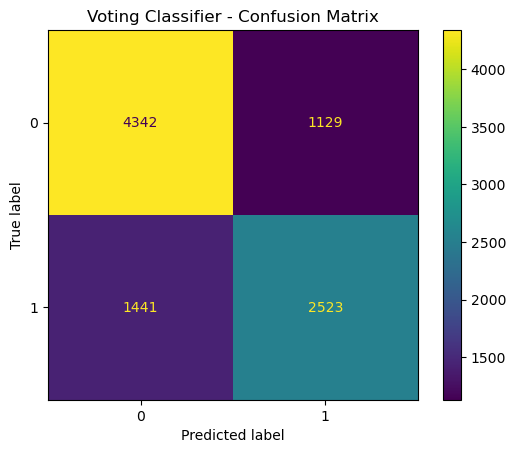

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import mutual_info_classif

# Load data
df = pd.read_csv(r'C:\Users\ASUS\Desktop\HeartDisease\cardiovasular heart disease\cardio_cleaned_no_outliers.csv')

# Feature engineering
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['interaction_alco_smoke'] = df['alco'] * df['smoke']
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, 100],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
df = pd.get_dummies(df, columns=['bmi_category'], drop_first=True)

# Drop highly correlated
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
df.drop(columns=to_drop, inplace=True)

# Feature selection
X = df.drop(columns=['id', 'cardio'])
y = df['cardio']
mi = mutual_info_classif(X, y)
selected_features = pd.Series(mi, index=X.columns)[lambda x: x > 0.01].index.tolist()
X = df[selected_features]

# Train-test split FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE only on training data
X_train_scaled, y_train = SMOTE(random_state=42).fit_resample(X_train_scaled, y_train)

# Faster RandomizedSearchCV for RF
rf_params = {'n_estimators': [100, 150], 'max_depth': [10, None]}
rf = RandomForestClassifier(random_state=42)
rf_best = RandomizedSearchCV(rf, rf_params, n_iter=2, cv=3, scoring='accuracy', random_state=42)
rf_best.fit(X_train_scaled, y_train)

# XGB fast tuning
xgb_params = {'n_estimators': [100], 'max_depth': [3, 5]}
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_best = RandomizedSearchCV(xgb, xgb_params, n_iter=2, cv=3, scoring='accuracy', random_state=42)
xgb_best.fit(X_train_scaled, y_train)

# SVC (no tuning, just basic)
svc = SVC(probability=True, kernel='rbf', C=1, random_state=42)
svc.fit(X_train_scaled, y_train)

# Voting classifier
voting_clf = VotingClassifier(estimators=[
    ('rf', rf_best.best_estimator_),
    ('xgb', xgb_best.best_estimator_),
    ('svc', svc)
], voting='soft')
voting_clf.fit(X_train_scaled, y_train)

# Predict
preds = voting_clf.predict(X_test_scaled)

# Results
print("\nAccuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))
ConfusionMatrixDisplay.from_estimator(voting_clf, X_test_scaled, y_test)
plt.title("Voting Classifier - Confusion Matrix")
plt.show()


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import mutual_info_classif

# Load data
df = pd.read_csv(r'C:\Users\ASUS\Desktop\HeartDisease\cardiovasular heart disease\cardio_cleaned_no_outliers.csv')

In [3]:
df.describe()

,id,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,31449.000000,31449.000000,31449.000000,31449.000000,31449.000000,31449.000000,31449.000000,31449.0,31449.0,31449.0,31449.0,31449.0,31449.000000
mean,50107.321823,52.427136,1.304207,164.200738,71.687609,124.539636,80.869280,1.0,1.0,0.0,0.0,1.0,0.424974
std,28781.406106,6.745641,0.460078,7.291806,11.731804,13.494804,7.335848,0.0,0.0,0.0,0.0,0.0,0.494347
min,0.000000,39.000000,1.000000,143.000000,40.000000,90.000000,65.000000,1.0,1.0,0.0,0.0,1.0,0.000000
25%,25110.000000,48.000000,1.000000,159.000000,64.000000,120.000000,80.000000,1.0,1.0,0.0,0.0,1.0,0.000000
50%,50031.000000,53.000000,1.000000,165.000000,70.000000,120.000000,80.000000,1.0,1.0,0.0,0.0,1.0,0.000000
75%,75094.000000,58.000000,2.000000,169.000000,79.000000,130.000000,80.000000,1.0,1.0,0.0,0.0,1.0,1.000000
max,99992.000000,64.000000,2.000000,186.000000,107.000000,170.000000,105.000000,1.0,1.0,0.0,0.0,1.0,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31449 entries, 0 to 31448
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           31449 non-null  int64  
 1   age_years    31449 non-null  int64  
 2   gender       31449 non-null  int64  
 3   height       31449 non-null  int64  
 4   weight       31449 non-null  float64
 5   ap_hi        31449 non-null  int64  
 6   ap_lo        31449 non-null  int64  
 7   cholesterol  31449 non-null  int64  
 8   gluc         31449 non-null  int64  
 9   smoke        31449 non-null  int64  
 10  alco         31449 non-null  int64  
 11  active       31449 non-null  int64  
 12  cardio       31449 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 3.1 MB
